### This notebook has binary classification related topics for logistic regression


In [14]:
#importing necessary files
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
#generating random data 
np.random.seed(42)
n_samples = 200
n_features = 2

X = np.random.randn(n_samples, n_features)

w_true = np.array([2.0, -1.0])
b_true = 0.5
Z = X @ w_true + b_true

In [ ]:
#sigmoid function 
def sigmoid(z):
    """Compute the sigmoid function"""
    return 1 / (1 + np.exp(-z))

# Probabilities
p = sigmoid(Z)

# Sample labels from probabilities
y = (np.random.rand(n_samples) < p).astype(int)

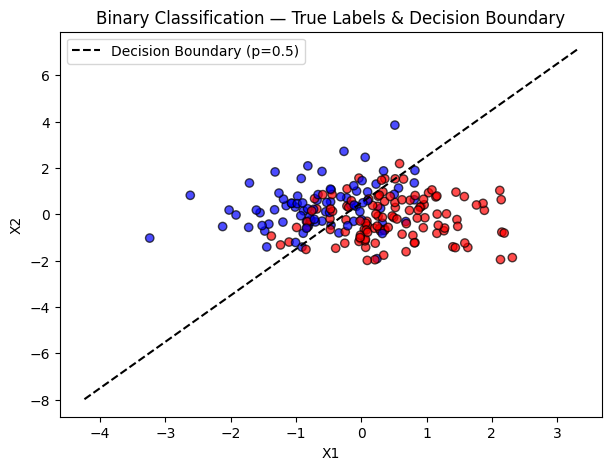

In [17]:
#plotting decision boundary
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k', alpha=0.7)
x1_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_vals = -(w_true[0]*x1_vals + b_true)/w_true[1]
plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary (p=0.5)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Binary Classification — True Labels & Decision Boundary')
plt.legend()
plt.show()

The plot shows the generated 2D points with their true class labels.<br>
The dashed line represents the decision boundary where the model predicts p = 0.5.<br>
Points on one side of the line are mostly class 1, and points on the other side are mostly class 0.<br>
Near the boundary, there are points of both classes — this shows the probabilistic nature of logistic regression.<br>
The linear boundary visually separates the classes, reflecting the linear relationship defined by w_true and b_true.<br>

Sample probabilities:
 [0.83640138 0.56766905 0.56606894 0.94739928 0.2725925  0.50972237
 0.94770809 0.08412715 0.13706199 0.52404533]


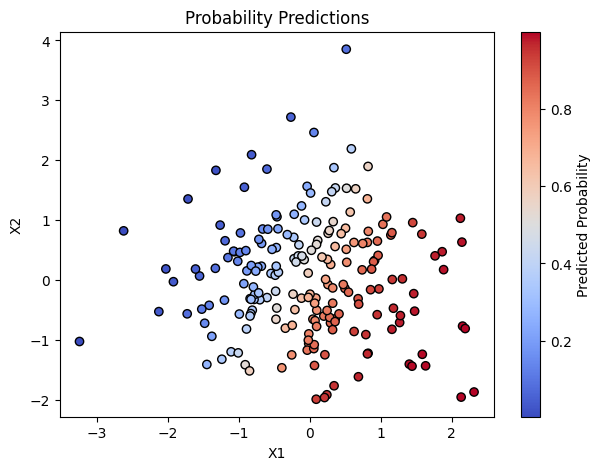

In [18]:
#probability predictions 
p = sigmoid(X @ w_true + b_true)
print("Sample probabilities:\n", p[:10])  # show first 10 for brevity

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=p, cmap='coolwarm', edgecolor='k')
plt.colorbar(label='Predicted Probability')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Probability Predictions')
plt.show()

Each point is now colored according to the predicted probability of being class 1.<br>
Redder points indicate higher probability (p closer to 1), blue points lower probability (p closer to 0).<br>
The color gradient shows a smooth transition of probabilities across the feature space — this is the effect of the sigmoid function.<br>
The probability is highest on the side of the boundary corresponding to class 1, and lowest on the side of class 0.<br>
This plot demonstrates that logistic regression outputs probabilities, not hard labels, which allows thresholding later<br>

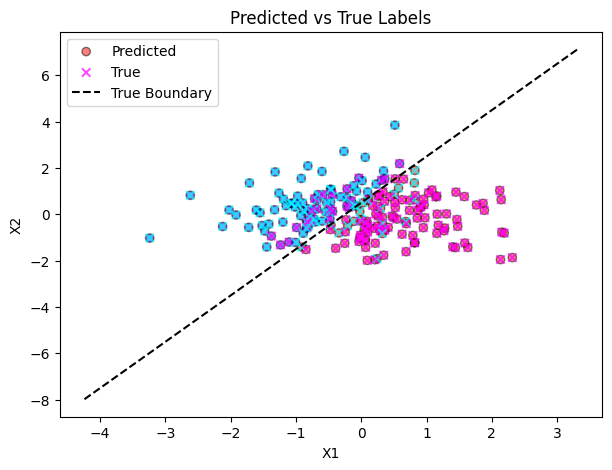

In [19]:
#threshold to class preditions 
threshold = 0.5
y_pred = (p >= threshold).astype(int)

plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='bwr', edgecolor='k', alpha=0.5, label='Predicted')
plt.scatter(X[:,0], X[:,1], c=y, cmap='cool', marker='x', alpha=0.7, label='True')
plt.plot(x1_vals, x2_vals, 'k--', label='True Boundary')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Predicted vs True Labels')
plt.legend()
plt.show()

Points are now shown with predicted labels (based on threshold 0.5) as filled circles, and true labels as crosses.<br>
Most predictions match the true labels, indicating that the decision boundary is a reasonable separator.<br>
Some points near the boundary are misclassified — this is expected due to probabilistic overlap.<br>
This visualization shows how thresholding probabilities produces class predictions.<br>
Helps understand the trade-off between threshold selection and classification errors, which will become important for precision/recall analysis later.<br>

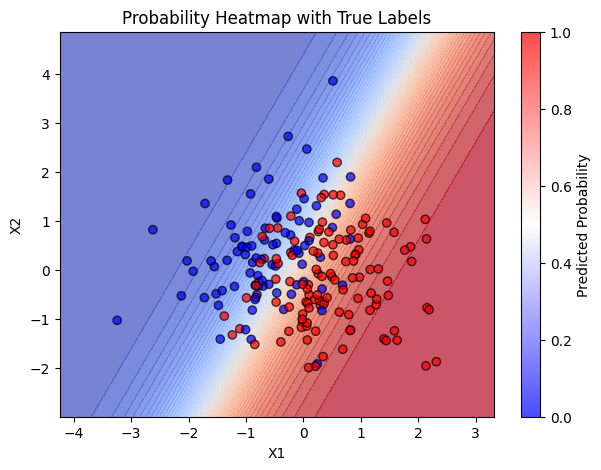

In [20]:
# Probability Heatmap

x1_range = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
x2_range = np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

Z_grid = w_true[0]*xx1 + w_true[1]*xx2 + b_true
p_grid = sigmoid(Z_grid)

plt.figure(figsize=(7,5))
plt.contourf(xx1, xx2, p_grid, levels=50, cmap='coolwarm', alpha=0.7)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap='bwr', alpha=0.7)
plt.colorbar(label='Predicted Probability')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Probability Heatmap with True Labels')
plt.show()

The color gradient shows how the predicted probability smoothly changes across the 2D feature space.<br>
Dark red areas indicate regions with high probability of class 1, dark blue areas indicate high probability of class 0.<br>
The heatmap confirms the linear decision boundary visually — the 0.5 probability contour matches the dashed line in the first plot.<br>
Points near the boundary have intermediate probabilities (purple shades), showing uncertainty.<br>
This plot makes it clear why logistic regression is suitable for probabilistic predictions, rather than hard thresholding alone.<br>
Helps understand that misclassifications occur near the boundary, which is a natural consequence of overlapping class distributions.<br>

### Overall
These three plots together illustrate how logistic regression works: it transforms a linear combination of features into probabilities using the sigmoid function, visualizes a decision boundary at p = 0.5, and then applies a threshold to make discrete class predictions.